Original X shape:  (19020, 10)
Binarized X shape: (19020, 38)
Binning map: {0: [0, 1, 2, 3, 4, 5, 37], 1: [6, 7, 8, 9, 10, 11], 2: [12, 13, 14, 15, 16], 6: [17, 18, 19, 20], 8: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]}
Best objective: 4618
Minimum objective: (0.242797)
Objective bound: 4664
Minimum objective: 4503
Cache sizes - Greedy: 17282, Lickety: 69558, Trie: 0, Trie cache: OFF
 4503
Rashomon set size: 4862
Objective = 4503, Count = 2
Objective = 4505, Count = 2
Objective = 4507, Count = 2
Objective = 4508, Count = 3
Objective = 4510, Count = 3
Objective = 4511, Count = 1
Objective = 4512, Count = 5
Objective = 4514, Count = 2
Objective = 4515, Count = 4
Objective = 4517, Count = 1
Objective = 4519, Count = 2
Objective = 4520, Count = 1
Objective = 4521, Count = 2
Objective = 4522, Count = 4
Objective = 4525, Count = 5
Objective = 4526, Count = 1
Objective = 4527, Count = 2
Objective = 4528, Count = 8
Objective = 4529, Count = 4
Objective = 4530, Count = 5


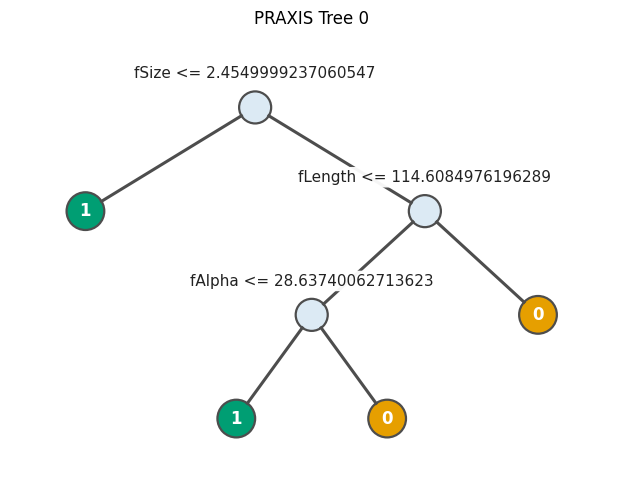

Tree 4861
Objective (raw):        4664
Objective (normalized): 0.245216
Training accuracy:      0.8047
First 10 predictions:   [1 1 0 1 1 1 1 1 1 1]
Number of leaves:       5
Root-to-leaf paths:
[+37, +35] -> 1
[+37, -35, +16] -> 1
[+37, -35, -16] -> 0
[-37, +25] -> 1
[-37, -25] -> 0


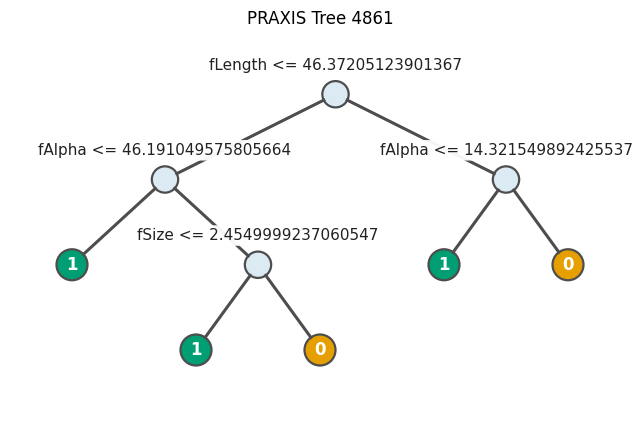

Best objective: 4590 (0.241325)
Objective bound: 4636
Minimum objective: 4584
Cache sizes - Greedy: 11770, Lickety: 28841, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 1 / 5 with 116 trees
Best objective: 4587 (0.241167)
Objective bound: 4633
Minimum objective: 4521
Cache sizes - Greedy: 15300, Lickety: 47943, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 2 / 5 with 1005 trees
Best objective: 4579 (0.240747)
Objective bound: 4625
Minimum objective: 4503
Cache sizes - Greedy: 15589, Lickety: 54373, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 3 / 5 with 1838 trees
Best objective: 4571 (0.240326)
Objective bound: 4617
Minimum objective: 4504
Cache sizes - Greedy: 15952, Lickety: 54133, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 4 / 5 with 752 trees
Best objective: 4579 (0.240747)
Objective bound: 4625
Minimum objective: 4579
Cache sizes - Greedy: 11503, Lickety: 23523, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 5 / 5 with 64 trees


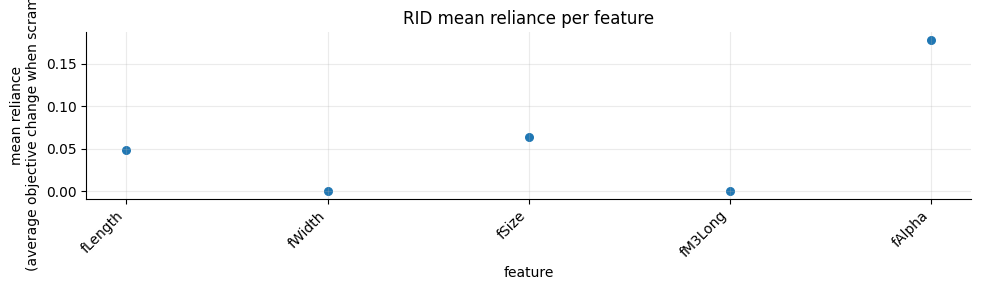

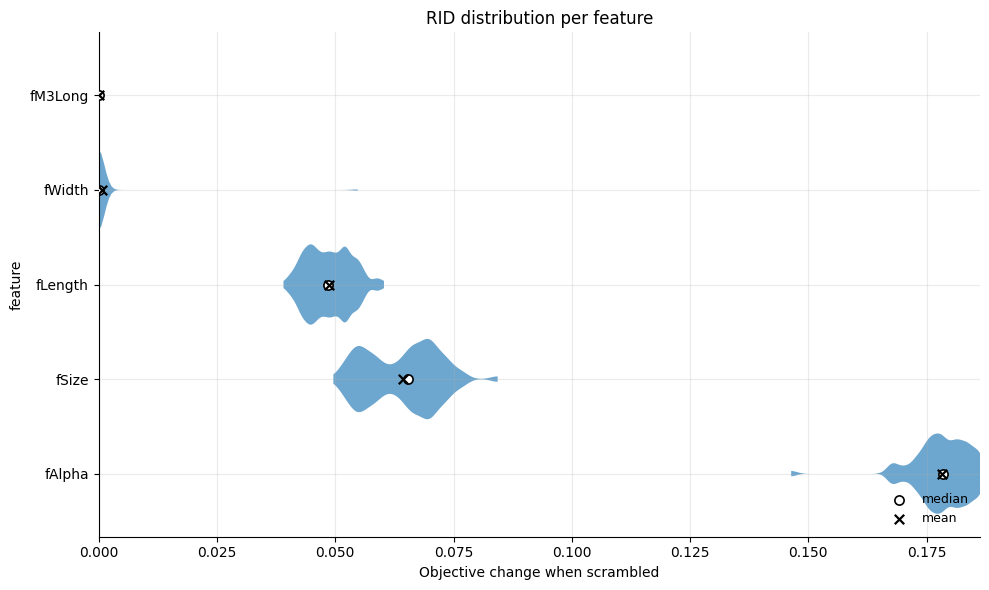

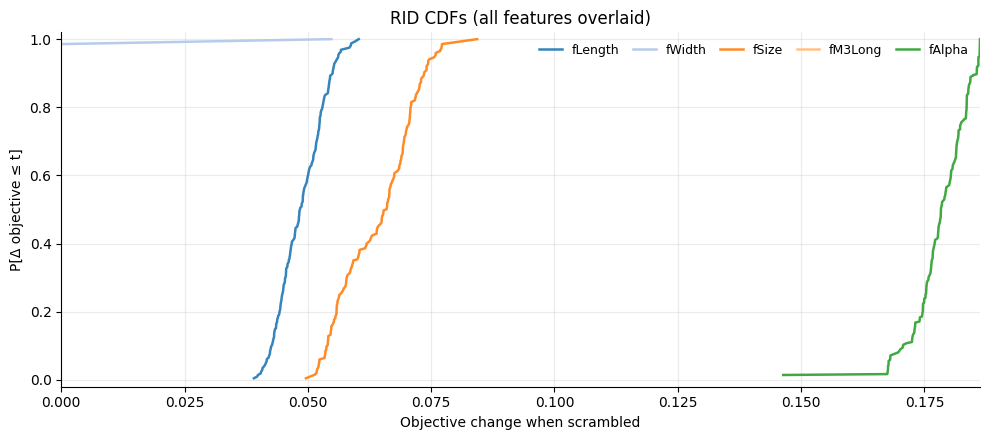

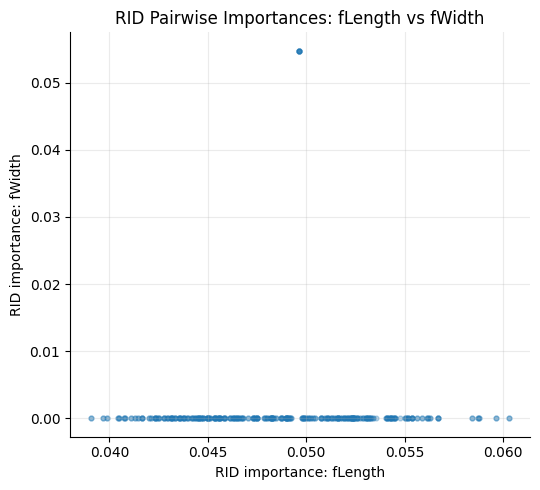

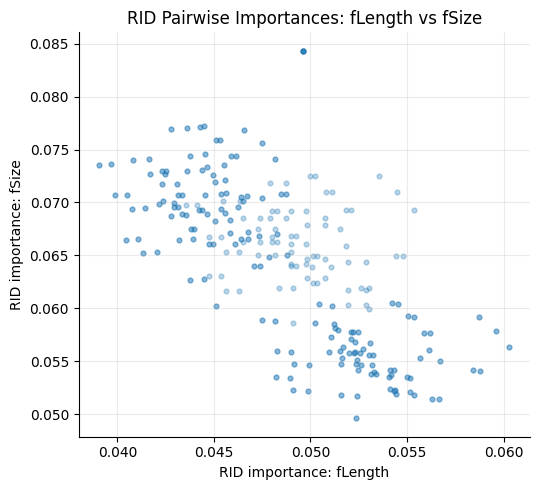

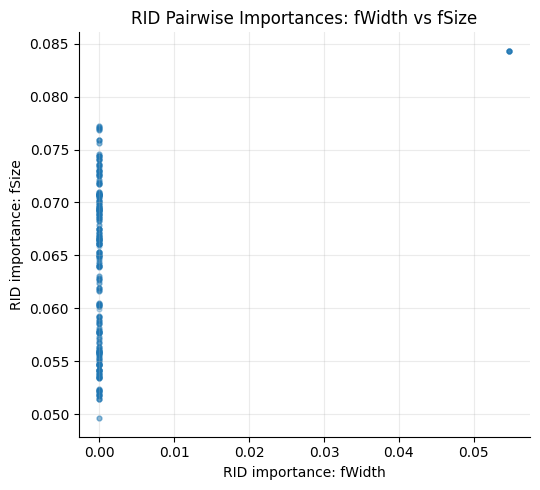

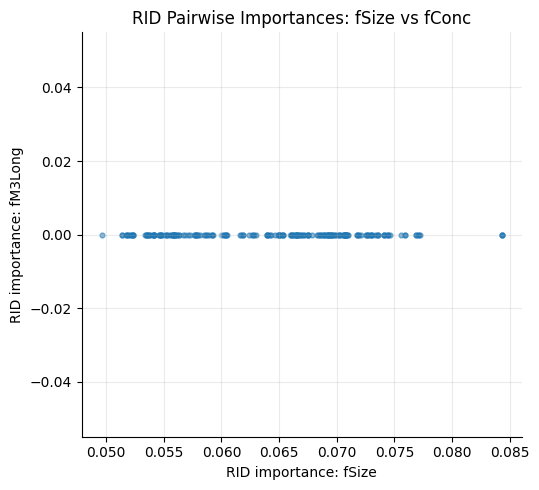

In [9]:
import numpy as np
from ucimlrepo import fetch_ucirepo
from praxis import PRAXIS, ThresholdGuessBinarizer


def accuracy(y_true, y_pred):
    return (np.asarray(y_true).astype(int) == np.asarray(y_pred).astype(int)).mean()


# Load MAGIC Gamma Telescope dataset
magic = fetch_ucirepo(id=159)
X_raw = magic.data.features.copy()
y_raw = magic.data.targets.copy()

y_col = y_raw.columns[0]
y = (y_raw[y_col] == "g").to_numpy(np.int64)


# binarize continuous features with theoretical guarantees relative to XGBoost
enc = ThresholdGuessBinarizer(
    n_estimators=50,
    max_depth=1,
    random_state=0,
    column_elimination=True,
)

X = enc.fit_transform(X_raw, y).astype(np.uint8)
binning_map = enc.feature_map() # this tells you what what binary columns in X the original column indices in X_raw map to

print("Original X shape: ", X_raw.shape)
print("Binarized X shape:", X.shape)
print("Binning map:", binning_map)


# Fit a Rashomon Set using the PRAXIS algorithm
model = PRAXIS()

model.fit(
    X, y,
    lambda_reg=0.01, # regularization on the number of leaves, lower means more leaves
    depth_budget=5, # the maximum number of splits along a path
    rashomon_mult=0.01, # the deviation from the optimal tree allowed
    multiplicative_slack=0,
    key_mode="hash",
    lookahead_k=1, # how strong of a proxy algorithm should we use. A greedy algorithm is 0, the LicketySPLIT algorithm (our preferred proxy algorithm) is 1. An optimal proxy (thus giving an optimal Rashomon set) is gotten at lookahead depth_budget-1
)

print("\nMinimum objective:", model.get_min_objective()) # the best tree found
print("Rashomon set size:", model.count_trees()) 

for obj, cnt in model.get_root_histogram():
    print(f"Objective = {obj}, Count = {cnt}")


# Inspect first and last trees in the Rashomon set (trees are ordered in increasing order of objective - that is tree 0 is the best tree)
num_trees = model.count_trees()

for tree_idx in [0, num_trees - 1]:
    print("=" * 60)
    print(f"Tree {tree_idx}")

    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    preds = model.get_predictions(tree_idx, X)
    paths_str, leaf_preds = model.get_tree_paths_str(tree_idx)

    print(f"Objective (raw):        {obj_raw}")
    print(f"Objective (normalized): {obj_norm:.6f}")
    print(f"Training accuracy:      {accuracy(y, preds):.4f}")
    print(f"First 10 predictions:   {preds[:10]}")
    print(f"Number of leaves:       {len(paths_str)}")

    print("Root-to-leaf paths:")
    for path, pred in zip(paths_str, leaf_preds):
        print(path, "->", pred)

    model.plot_tree(tree_idx, feature_names=enc.get_feature_names_out(), title=f"PRAXIS Tree {tree_idx}", show=True)


# compute and plot the Rashomon Importance Distribution (variable importance over all good models)
model.compute_rid(
    X, y,
    n_boot=5, # number of bootstraps to do this over
    n_scramble_evals=2,
    lambda_reg=0.01,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    seed=0,
    binning_map=binning_map,
    return_joint_samples=True # more memory, but allows you to look at joint relationships
)

feature_names = list(enc.feature_names_in_)

model.rid_plot_mean(feature_names=feature_names)
model.rid_plot_violin(feature_names=feature_names)
model.rid_plot_cdfs(feature_names=feature_names)

# joint relationships
pairs = [
    (0, 1),
    (0, 2),
    (1, 2),
    (2, 3),
]

for j, k in pairs:
    model.rid_plot_pair(
        j,
        k,
        feature_names=feature_names,
        title=f"RID Pairwise Importances: {feature_names[j]} vs {feature_names[k]}",
        alpha=0.30,
        s=12,
    )

Minimum objective:Best objective:  80
Rashomon set size: 33
Histogram entries: [(80, 12), (81, 8), (82, 5), (84, 8)]
Objective = 80, Count = 12
Objective = 81, Count = 8
Objective = 82, Count = 5
Objective = 84, Count = 8

Total Rashomon trees: 33

Tree 0
Objective (raw):      80
Objective (normalized): 0.080000

Predictions from tree 0 (first 10 samples):
[1 0 0 0 0 0 1 1 1 1]
Training accuracy (tree 0): 1.0000

Tree 0 has 8 leaves.
All root-to-leaf paths:
[+2, +3, +14] -> 0
[+2, +3, -14] -> 1
[+2, -3, +14] -> 1
[+2, -3, -14] -> 0
[-2, +3, +14] -> 1
[-2, +3, -14] -> 0
[-2, -3, +14] -> 0
[-2, -3, -14] -> 1
80 (0.08)
Objective bound: 84
Minimum objective: 80
Cache sizes - Greedy: 2172, Lickety: 3681, Trie: 0, Trie cache: OFF


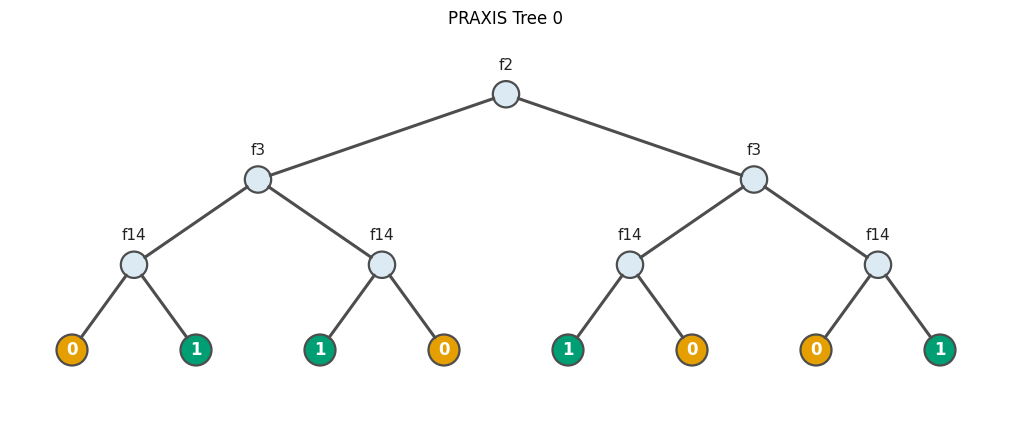

Tree 32
Objective (raw):      84
Objective (normalized): 0.084000

Predictions from tree 32 (first 10 samples):
[1 0 0 0 0 0 1 1 1 1]
Training accuracy (tree 32): 0.9960

Tree 32 has 8 leaves.
All root-to-leaf paths:
[+14, +3, +12] -> 0
[+14, +3, -12] -> 1
[+14, -3, +2] -> 1
[+14, -3, -2] -> 0
[-14, +3, +2] -> 1
[-14, +3, -2] -> 0
[-14, -3, +2] -> 0
[-14, -3, -2] -> 1


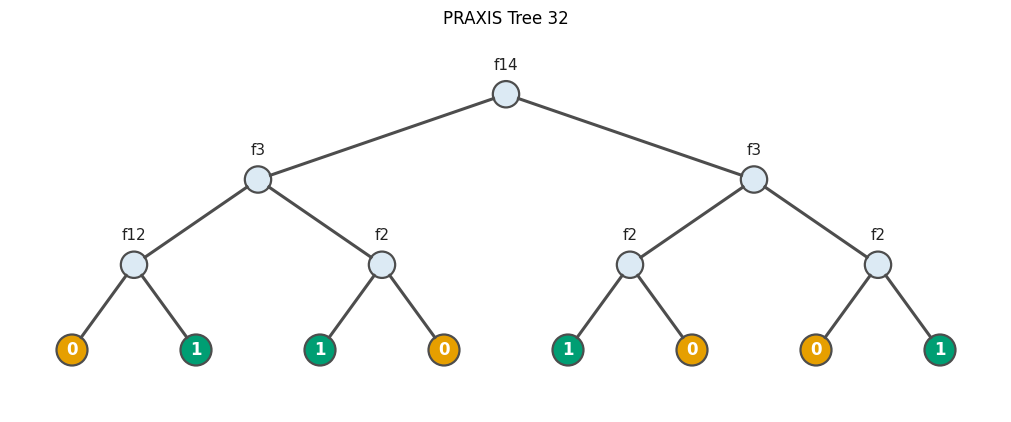


[Dimensionality] Number of trees in all_preds_list: 33
[Dimensionality] Shape of first tree's prediction vector: (1000,)

[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples): (33, 1000)
Majority-vote predictions (first 10 samples):
[1 0 0 0 0 0 1 1 1 1]


In [2]:
import numpy as np
from praxis import PRAXIS
import matplotlib.pyplot as plt

def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    return (y_true == y_pred).mean()

n_samples = 1000
n_features = 10

rng = np.random.default_rng(0)

X = (rng.random((n_samples, n_features)) > 0.5).astype(np.uint8)

# label: odd/even parity of first 4 features
three_sum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
y = (three_sum % 2).astype(int)

# extra feature for interest: 1 if x1 + x2 is even, 0 otherwise
sum_01 = X[:, 0] + X[:, 1]
even_01 = ((sum_01 % 2) == 0).astype(np.uint8)

# make 4 noisy copies of the first 4 columns
# each entry is flipped with probability 1/100
base_four = X[:, :4].copy()
flip_mask = (rng.random((n_samples, 4)) < 0.01).astype(np.uint8)  # 1 with prob 0.01, else 0
noisy_four = base_four ^ flip_mask  # XOR to flip bits where flip_mask == 1

# append these extra features
X = np.hstack([X, noisy_four, even_01[:, None]])


model = PRAXIS()

model.fit(
    X, y,
    lambda_reg=0.01,        # sparsity penalty - recommended
    depth_budget=5,         # max tree depth as defined by number of splits along any path
    rashomon_mult=0.05,     # rashomon bound: 5% worse than initial oracle objective
    # optional parameters (default is sufficient)
    multiplicative_slack=0, # extra slack factor 
    key_mode="hash",        # "hash" for memory savings at an astronomically low change of error or "exact"
    lookahead_k=1, # 1 = LicketySPLIT oracle, 0 = greedy, >1 higher-tiered oracles
)

print("Minimum objective:", model.get_min_objective())
print("Rashomon set size:", model.count_trees())

hist = model.get_root_histogram()
print("Histogram entries:", hist)

for obj, cnt in hist:
    print(f"Objective = {obj}, Count = {cnt}")

# we will inspect the first and last trees
num_trees = model.count_trees()
tree_indices = [0, num_trees - 1]

print(f"\nTotal Rashomon trees: {num_trees}\n")

for tree_idx in tree_indices:
    print("=" * 60)
    print(f"Tree {tree_idx}")
    
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print(f"Objective (raw):      {obj_raw}")
    print(f"Objective (normalized): {obj_norm:.6f}")

    preds_i = model.get_predictions(tree_idx, X)
    print(f"\nPredictions from tree {tree_idx} (first 10 samples):")
    print(preds_i[:10])
    
    acc_i = accuracy(y, preds_i)
    print(f"Training accuracy (tree {tree_idx}): {acc_i:.4f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"\nTree {tree_idx} has {len(paths_str)} leaves.")

    print("All root-to-leaf paths:")
    for s, p in zip(paths_str, preds):
        print(s, "->", p)

    model.plot_tree(tree_idx, title=f"PRAXIS Tree {tree_idx}", show=True)
    
# list-of-vectors version
all_preds_list = model.get_all_predictions(X, stack=False)
print(f"\n[Dimensionality] Number of trees in all_preds_list: {len(all_preds_list)}")
if len(all_preds_list) > 0:
    print("[Dimensionality] Shape of first tree's prediction vector:",
          all_preds_list[0].shape)

# stacked matrix version
all_preds_mat = model.get_all_predictions(X, stack=True)
print("\n[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples):",
      all_preds_mat.shape)

majority_vote = (all_preds_mat.mean(axis=0) >= 0.5).astype(np.uint8)
print("Majority-vote predictions (first 10 samples):")
print(majority_vote[:10])


Minimum objective:Best objective:  600 (0.06)
Objective bound: 630
Minimum objective: 600
Cache sizes - Greedy: 0, Lickety: 77901, Trie: 0, Trie cache: OFF
600
Rashomon set size: 4464
Histogram entries: [(600, 360), (610, 128), (611, 52), (612, 256), (613, 128), (614, 564), (615, 52), (616, 156), (618, 104), (621, 16), (622, 188), (623, 72), (624, 448), (625, 198), (626, 618), (627, 238), (628, 382), (629, 236), (630, 268)]
Objective = 600, Count = 360
Objective = 610, Count = 128
Objective = 611, Count = 52
Objective = 612, Count = 256
Objective = 613, Count = 128
Objective = 614, Count = 564
Objective = 615, Count = 52
Objective = 616, Count = 156
Objective = 618, Count = 104
Objective = 621, Count = 16
Objective = 622, Count = 188
Objective = 623, Count = 72
Objective = 624, Count = 448
Objective = 625, Count = 198
Objective = 626, Count = 618
Objective = 627, Count = 238
Objective = 628, Count = 382
Objective = 629, Count = 236
Objective = 630, Count = 268

Total Rashomon trees: 44

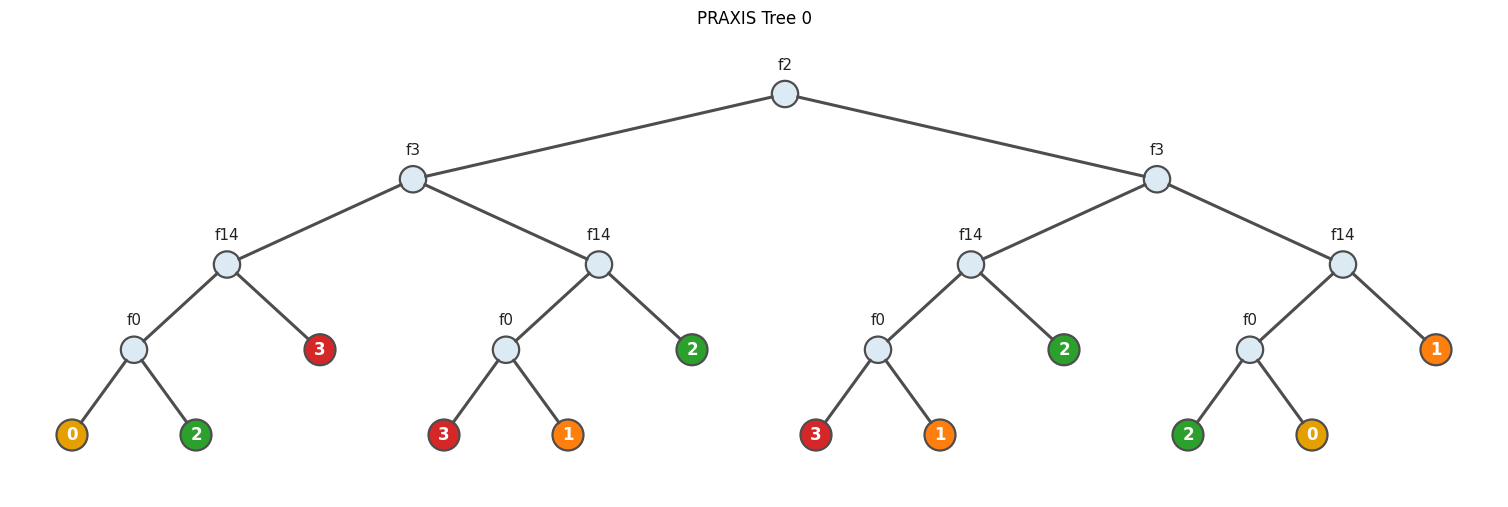

Tree 4463
Objective (raw):      630
Objective (normalized): 0.063000

Predictions from tree 4463 (first 10 samples):
[1 2 2 2 2 2 1 3 3 3]

Tree 4463 has 12 leaves.
All root-to-leaf paths:
[+14, +3, +1, +2] -> 0
[+14, +3, +1, -2] -> 3
[+14, +3, -1, +12] -> 2
[+14, +3, -1, -12] -> 1
[+14, -3, +2, +1] -> 3
[+14, -3, +2, -1] -> 1
[+14, -3, -2, +11] -> 2
[+14, -3, -2, -11] -> 0
[-14, +3, +2] -> 3
[-14, +3, -2] -> 2
[-14, -3, +2] -> 2
[-14, -3, -2] -> 1


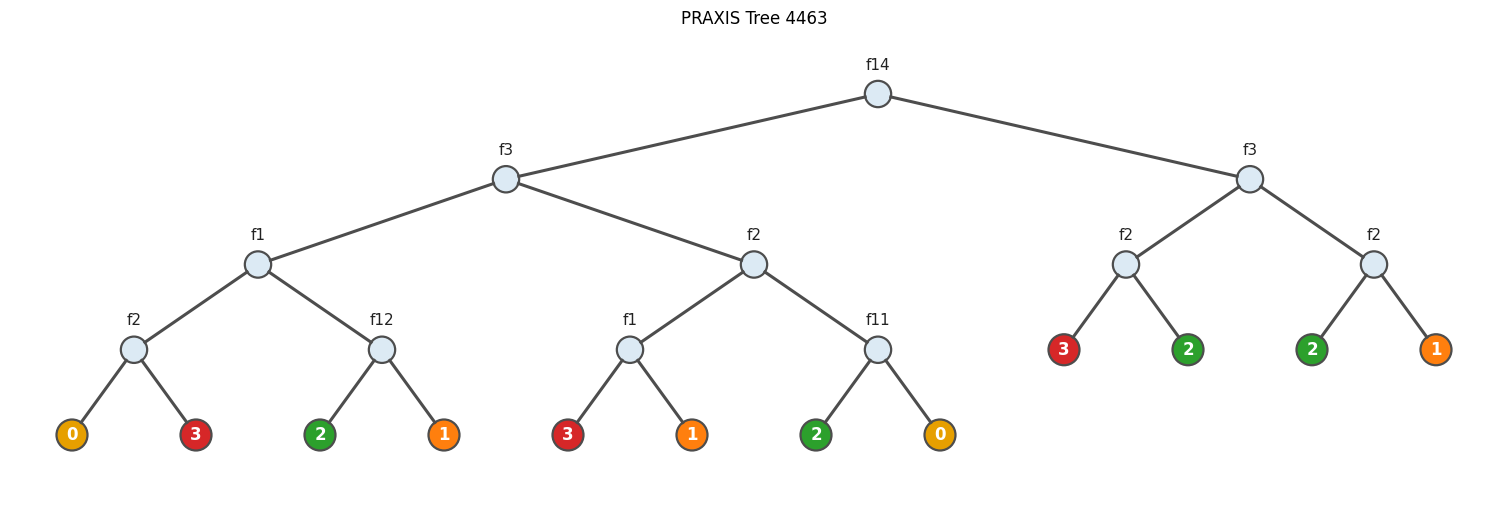


[Dimensionality] Number of trees in all_preds_list: 4464
[Dimensionality] Shape of first tree's prediction vector: (10000,)

[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples): (4464, 10000)
Majority-vote predictions (first 10 samples):
[1 2 2 2 2 2 1 3 3 3]


In [3]:
import numpy as np
from praxis import PRAXIS
import matplotlib.pyplot as plt

n_samples = 10000
n_features = 10

rng = np.random.default_rng(0)

X = (rng.random((n_samples, n_features)) > 0.5).astype(np.uint8)

# label: 4-parity of first 4 features
three_sum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
y = (three_sum % 4).astype(int)

# extra feature for interest: 1 if x1 + x2 is even, 0 otherwise
sum_01 = X[:, 0] + X[:, 1]
even_01 = ((sum_01 % 2) == 0).astype(np.uint8)

# make 4 noisy copies of the first 4 columns
# each entry is flipped with probability 1/100
base_four = X[:, :4].copy()
flip_mask = (rng.random((n_samples, 4)) < 0.01).astype(np.uint8)  # 1 with prob 0.01, else 0
noisy_four = base_four ^ flip_mask  # XOR to flip bits where flip_mask == 1

# append these extra features
X = np.hstack([X, noisy_four, even_01[:, None]])


model = PRAXIS()

model.fit(
    X, y,
    lambda_reg=0.005,        # sparsity penalty - recommended
    depth_budget=6,         # max tree depth as defined by number of splits along any path
    rashomon_mult=0.05,     # rashomon bound: 5% worse than initial oracle objective
    # optional parameters (default is sufficient)
    multiplicative_slack=0, # extra slack factor 
    key_mode="hash",        # "hash" for memory savings at an astronomically low change of error or "exact"
    lookahead_k=5, # 1 = LicketySPLIT oracle, 0 = greedy, >1 higher-tiered oracles
)

print("Minimum objective:", model.get_min_objective())
print("Rashomon set size:", model.count_trees())

hist = model.get_root_histogram()
print("Histogram entries:", hist)

for obj, cnt in hist:
    print(f"Objective = {obj}, Count = {cnt}")

# we will inspect the first and last trees
num_trees = model.count_trees()
tree_indices = [0, num_trees - 1]

print(f"\nTotal Rashomon trees: {num_trees}\n")

for tree_idx in tree_indices:
    print("=" * 60)
    print(f"Tree {tree_idx}")
    
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print(f"Objective (raw):      {obj_raw}")
    print(f"Objective (normalized): {obj_norm:.6f}")

    preds_i = model.get_predictions(tree_idx, X)
    print(f"\nPredictions from tree {tree_idx} (first 10 samples):")
    print(preds_i[:10])

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"\nTree {tree_idx} has {len(paths_str)} leaves.")

    print("All root-to-leaf paths:")
    for s, p in zip(paths_str, preds):
        print(s, "->", p)

    model.plot_tree(tree_idx, title=f"PRAXIS Tree {tree_idx}")

# list-of-vectors version
all_preds_list = model.get_all_predictions(X, stack=False)
print(f"\n[Dimensionality] Number of trees in all_preds_list: {len(all_preds_list)}")
if len(all_preds_list) > 0:
    print("[Dimensionality] Shape of first tree's prediction vector:",
          all_preds_list[0].shape)

# stacked matrix version
all_preds_mat = model.get_all_predictions(X, stack=True)
print("\n[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples):",
      all_preds_mat.shape)

majority_vote = all_preds_mat.mean(axis=0).round().astype(np.uint8)
print("Majority-vote predictions (first 10 samples):")
print(majority_vote[:10])


Best objective: 
RID mean_sub_mr (per feature):
  f0: 0.085053
  f1: 0.085168
  f2: 0.485721
  f3: 0.448102
  f4: 0.000000
  f5: 0.000000
  f6: 0.000000
  f7: 0.000000
  f8: 0.000000
  f9: 0.000000
 f10: 0.043335
 f11: 0.036925
 f12: 0.010848
 f13: 0.051556
 f14: 0.496024
120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 1906, Lickety: 2695, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 1 / 20 with 6047 trees
Best objective: 120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 1879, Lickety: 2750, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 2 / 20 with 7314 trees
Best objective: 120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 1924, Lickety: 2829, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 3 / 20 with 4157 trees
Best objective: 120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 1942, Lickety: 2795, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 4 / 20 with 3930 trees

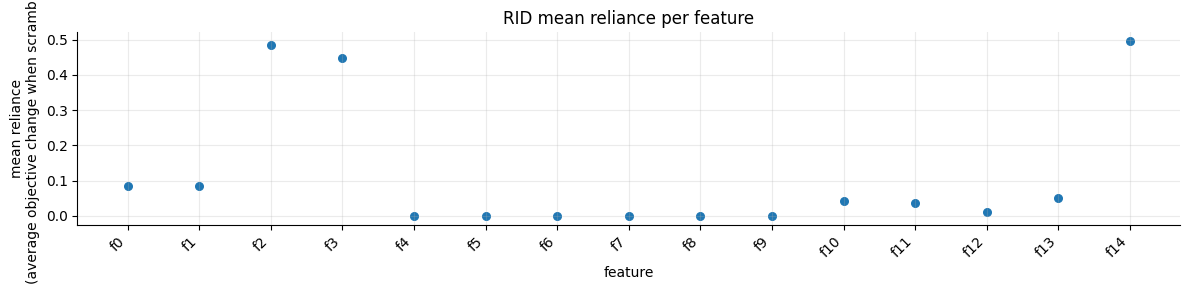

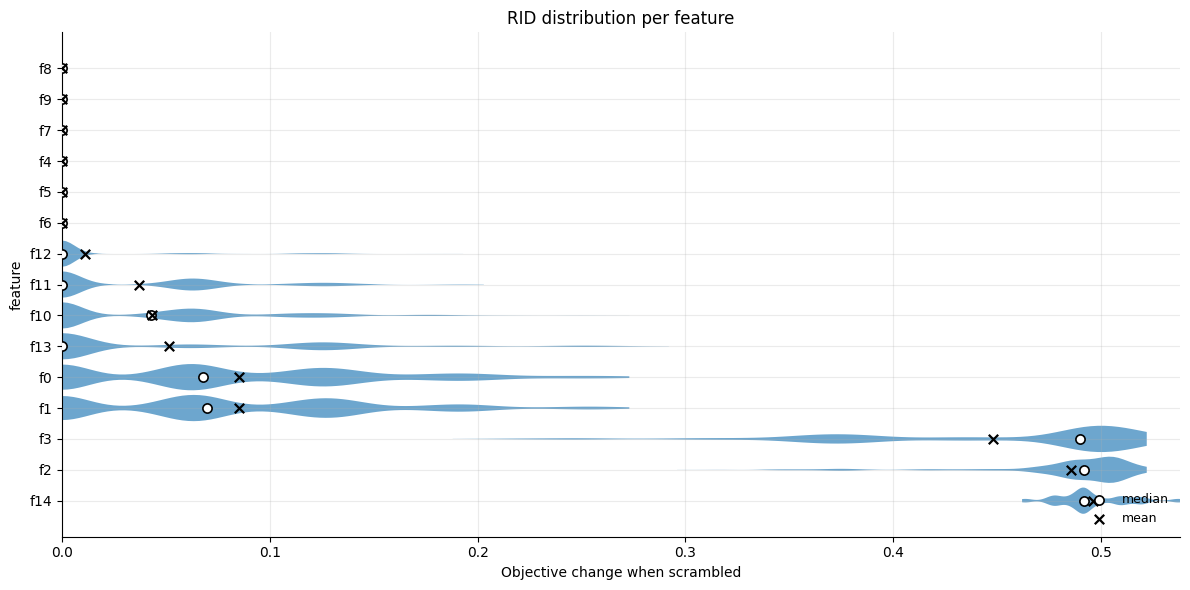

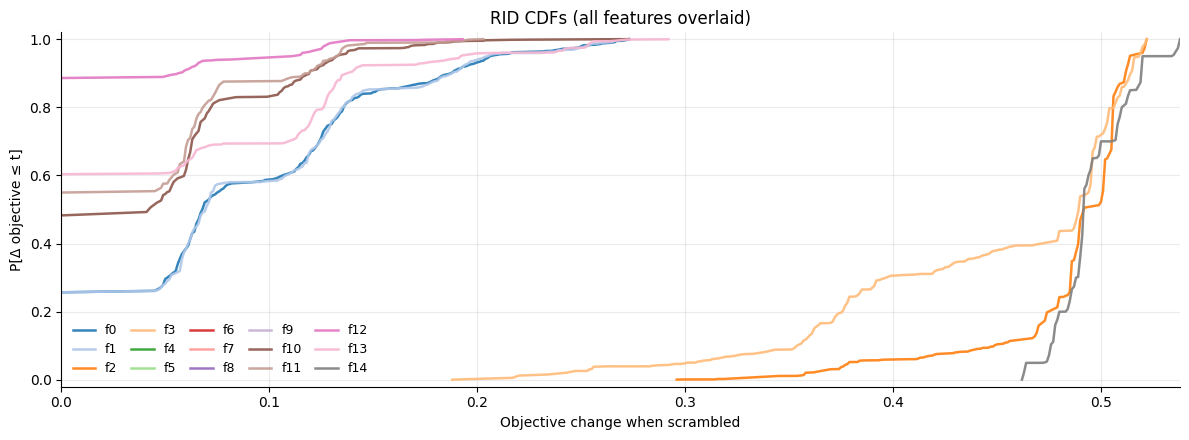

(<Figure size 1200x450 with 1 Axes>,
 <Axes: title={'center': 'RID CDFs (all features overlaid)'}, xlabel='Objective change when scrambled', ylabel='P[Δ objective ≤ t]'>)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from praxis import PRAXIS

n_samples = 1000
n_features = 10
rng = np.random.default_rng(0)

X = (rng.random((n_samples, n_features)) > 0.5).astype(np.uint8)

three_sum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
y = (three_sum % 4).astype(int)

sum_01 = X[:, 0] + X[:, 1]
even_01 = ((sum_01 % 2) == 0).astype(np.uint8)

base_four = X[:, :4].copy()
flip_mask = (rng.random((n_samples, 4)) < 0.01).astype(np.uint8)
noisy_four = base_four ^ flip_mask

X = np.hstack([X, noisy_four, even_01[:, None]])

feature_names = [f"f{j}" for j in range(X.shape[1])]

model = PRAXIS()
rid_out = model.compute_rid(
    X,
    y,
    n_boot=20,
    lambda_reg=0.01,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    seed=0,
    memory_efficient=False,
    binning_map=None,
)

mean = np.asarray(rid_out["mean_sub_mr"], dtype=float)
print("\nRID mean_sub_mr (per feature):")
for j, m in enumerate(mean):
    print(f"{feature_names[j]:>4}: {m:.6f}")

model.rid_plot_mean(feature_names=feature_names, figsize=(12, 3))
model.rid_plot_violin(feature_names=feature_names, figsize=(12, 6), samples_per_feature=4000, seed=123)
model.rid_plot_cdfs(feature_names=feature_names, figsize=(12, 4.5), legend_ncol=5, legend_fontsize=9)


Minimum objective:Best objective: 1674 1674
Rashomon set size: 227184388

Root histogram (objective_int, count):
  1674: 28
  1679: 28
  1680: 40
  1682: 14
  1683: 14
  1684: 236
  1685: 200
  1686: 484
  1687: 198
  1688: 576
  1689: 5918
  1690: 858
  1691: 672
  1692: 739
  1693: 1003
  1694: 5862
  1695: 8417
  1696: 2907
  1697: 5411
  1698: 6826
  1699: 42114
  1700: 39170
  1701: 85772
  1702: 47433
  1703: 105731
  1704: 628734
  1705: 165198
  1706: 140776
  1707: 166504
  1708: 214408
  1709: 661747
  1710: 1024800
  1711: 569136
  1712: 829888
  1713: 1090963
  1714: 4303611
  1715: 4307246
  1716: 8756152
  1717: 5998514
  1718: 11318485
  1719: 48621111
  1720: 18440530
  1721: 16742707
  1722: 20432197
  1723: 25579858
  1724: 56831172

Tree 0
  Objective (raw):        1674
  Objective (normalized): 0.337092
  Leaves: 5
 (0.337092)
Objective bound: 1724
Minimum objective: 1674
Cache sizes - Greedy: 16324, Lickety: 89581, Trie: 0, Trie cache: OFF


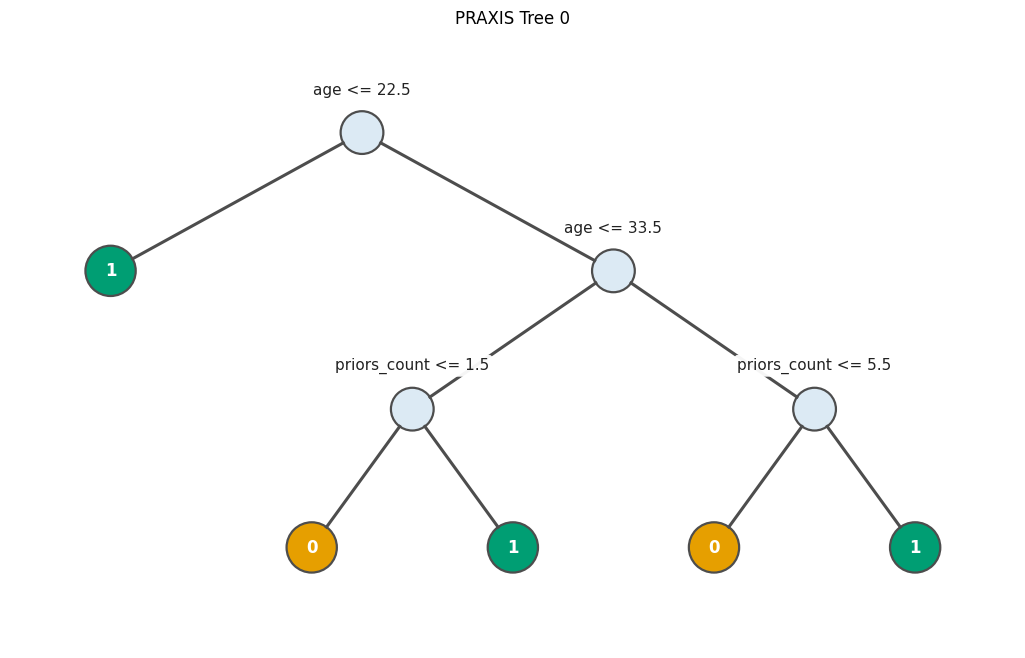


Tree 227184387
  Objective (raw):        1724
  Objective (normalized): 0.347161
  Leaves: 9


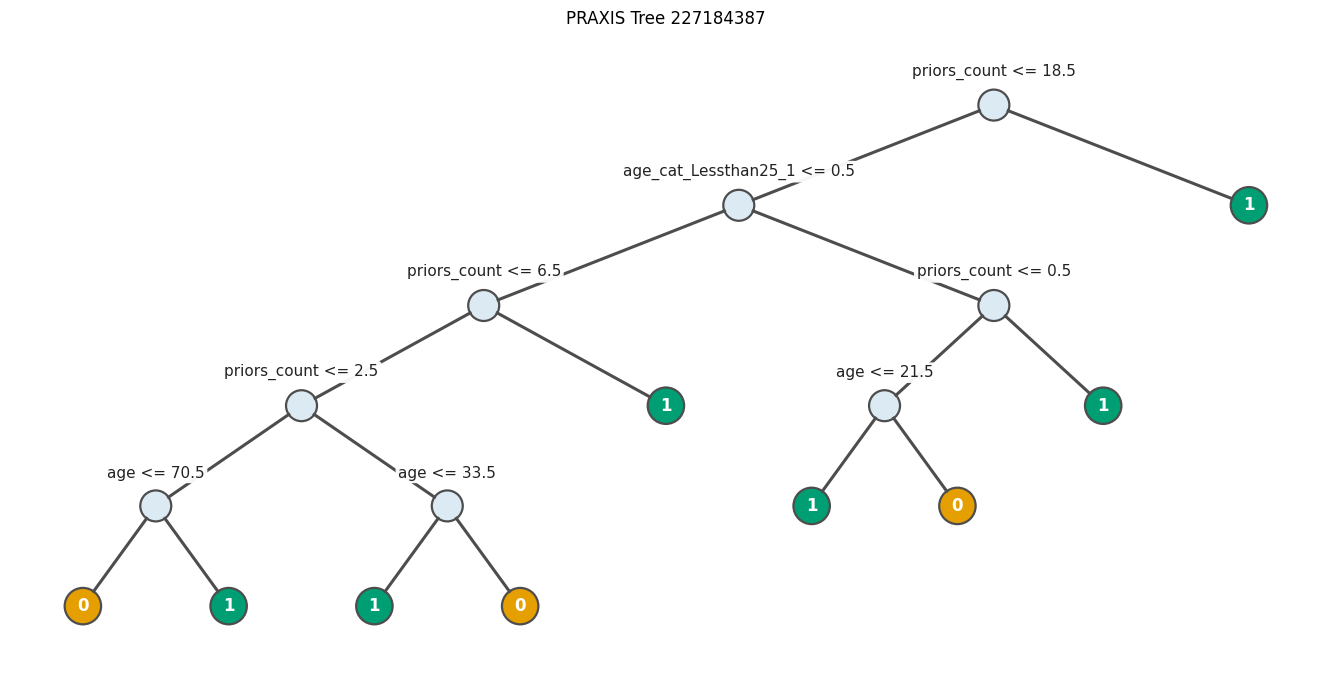

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from praxis import PRAXIS, ThresholdGuessBinarizer

df = pd.read_csv("compas_binarized.csv")

feature_names = df.columns[:-1].tolist()
X = df.iloc[:, :-1].to_numpy(dtype=np.uint8)
y = df.iloc[:, -1].to_numpy(dtype=int)

model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.003,
    depth_budget=5,
    rashomon_mult=0.03,
    multiplicative_slack=0.0,
    key_mode="hash",
    lookahead_k=1,
)

print("Minimum objective:", model.get_min_objective())
num_trees = model.count_trees()
print("Rashomon set size:", num_trees)

hist = model.get_root_histogram()
print("\nRoot histogram (objective_int, count):")
for obj, cnt in hist:
    print(f"  {obj}: {cnt}")

tree_indices = [0, num_trees - 1] if num_trees > 1 else [0]

for tree_idx in tree_indices:
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print("\n" + "=" * 60)
    print(f"Tree {tree_idx}")
    print(f"  Objective (raw):        {obj_raw}")
    print(f"  Objective (normalized): {obj_norm:.6f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"  Leaves: {len(paths_str)}")

    model.plot_tree(tree_idx, feature_names=feature_names, figsize=(20, 8),title=f"PRAXIS Tree {tree_idx}")



Best objective: 1699 (0.342126)
Objective bound: 1716
Minimum objective: 1699
Cache sizes - Greedy: 54868, Lickety: 32435, Trie: 0, Trie cache: OFF
Minimum objective: 1699
Rashomon set size: 272

Root histogram (objective_int, count):
  1699: 28
  1704: 28
  1707: 14
  1708: 14
  1710: 40
  1712: 14
  1713: 14
  1714: 36
  1716: 84

Tree 0
  Objective (raw):        1699
  Objective (normalized): 0.342126
  Leaves: 5


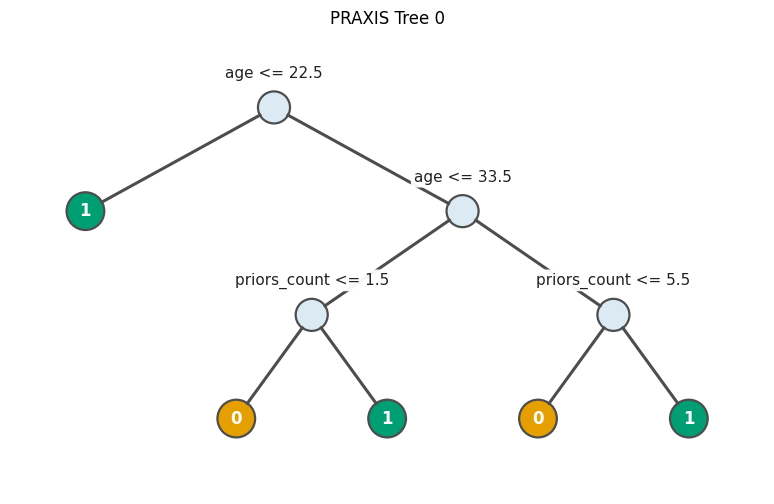


Tree 271
  Objective (raw):        1716
  Objective (normalized): 0.345550
  Leaves: 6


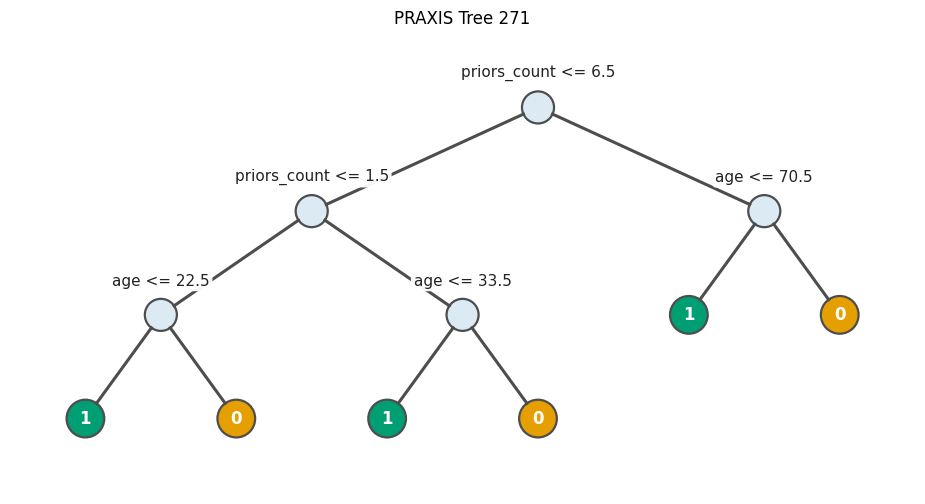


Per-sample p_i summary (across all trees):
  mean(p_i) = 0.4769
  min(p_i)  = 0.0000
  max(p_i)  = 1.0000

Per-sample disagreement (variance) summary (across all trees):
  mean(var) = 0.013265
  min(var)  = 0.000000
  max(var)  = 0.250000

Average disagreement across samples: 0.013265


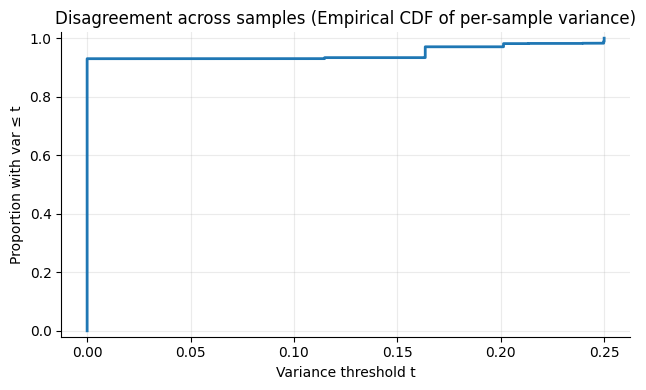

(<Figure size 650x400 with 1 Axes>,
 <Axes: title={'center': 'Disagreement across samples (Empirical CDF of per-sample variance)'}, xlabel='Variance threshold t', ylabel='Proportion with var ≤ t'>)

In [6]:
# deeper trees
model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.004,
    depth_budget=7,
    rashomon_mult=0.01,
    multiplicative_slack=0.0,
    key_mode="hash",
    lookahead_k=1,
)

print("Minimum objective:", model.get_min_objective())
num_trees = model.count_trees()
print("Rashomon set size:", num_trees)

hist = model.get_root_histogram()
print("\nRoot histogram (objective_int, count):")
for obj, cnt in hist:
    print(f"  {obj}: {cnt}")

tree_indices = [0, num_trees - 1] if num_trees > 1 else [0]

for tree_idx in tree_indices:
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print("\n" + "=" * 60)
    print(f"Tree {tree_idx}")
    print(f"  Objective (raw):        {obj_raw}")
    print(f"  Objective (normalized): {obj_norm:.6f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"  Leaves: {len(paths_str)}")

    model.plot_tree(tree_idx, feature_names=feature_names, figsize=(14, 6), title=f"PRAXIS Tree {tree_idx}")

# disagreement/uncertainty metrics (for binary classification only)
# p_i per sample: proportion of trees predicting 1 for each sample i
p_all = model.get_p_per_sample(X)
print("\nPer-sample p_i summary (across all trees):")
print(f"  mean(p_i) = {float(np.mean(p_all)):.4f}")
print(f"  min(p_i)  = {float(np.min(p_all)):.4f}")
print(f"  max(p_i)  = {float(np.max(p_all)):.4f}")

# variance per sample: var of hard predictions across trees
# p(1-p), this takes a maximum value of 0.25. if there is a value of 0.25, it means half the trees predict 1 and half predict 0.
v_all = model.get_variance_per_sample(X)  # shape (N,)
print("\nPer-sample disagreement (variance) summary (across all trees):")
print(f"  mean(var) = {float(np.mean(v_all)):.6f}")
print(f"  min(var)  = {float(np.min(v_all)):.6f}")
print(f"  max(var)  = {float(np.max(v_all)):.6f}")

# average variance across samples (can also derive as mean of above)
avg_var = model.get_avg_variance_across_samples(X)
print(f"\nAverage disagreement across samples: {avg_var:.6f}")

# proportion of samples with variance <= t
model.plot_disagreement_cdf(X, title="Disagreement across samples (Empirical CDF of per-sample variance)")

Single-tree objective: 
Tree 0
  Objective (raw):        1603
  Objective (normalized): 0.322795
1603 (0.322795)
  preds[:10]: [0 1 0 1 1 0 0 0 0 0]
  Training accuracy: 0.6892871526379379
  Leaves: 12


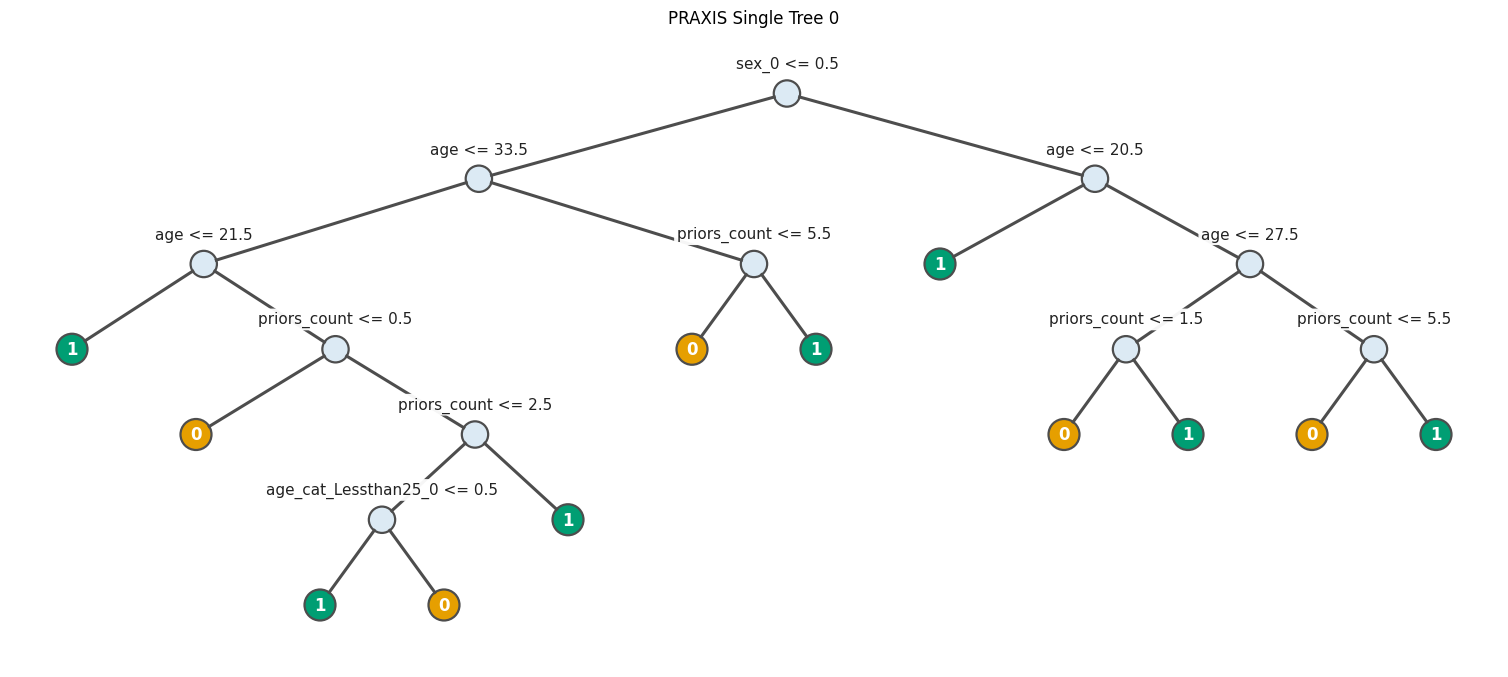

(<Figure size 1920x980 with 1 Axes>,
 <Axes: title={'center': 'PRAXIS Single Tree 0'}>)

In [7]:
import numpy as np

def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    return (y_true == y_pred).mean()

# this script shows how you can use PRAXIS to find just a single tree (set proxy_only=True and it'll directly run the proxy algorithm)
model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.001,
    depth_budget=10,
    key_mode="hash",
    lookahead_k=1, # in single tree mode, lookahead_k specifies the decision tree algorithm: 0 for greedy, 1 for LicketySPLIT, and 2+ for generalizations of LicketySPLIT. lookahead_k=d-1 is optimal.
    proxy_only=True, # single tree mode
)

tree_idx = 0 # only one tree in single-tree mode, index 0 is it

obj_raw, obj_norm = model.get_tree_objective(tree_idx)
print("\n" + "=" * 60)
print(f"Tree {tree_idx}")
print(f"  Objective (raw):        {obj_raw}")
print(f"  Objective (normalized): {obj_norm:.6f}")

# predictions + accuracy
y_hat = model.get_predictions(tree_idx, X).astype(np.uint8)
print("  preds[:10]:", y_hat[:10])
print("  Training accuracy:", accuracy(y, y_hat))

# paths + plot
paths_str, preds = model.get_tree_paths_str(tree_idx)
print(f"  Leaves: {len(paths_str)}")

model.plot_tree(tree_idx, feature_names=feature_names, figsize=(14, 6), title=f"PRAXIS Single Tree {tree_idx}")


In [8]:
import numpy as np
from ucimlrepo import fetch_ucirepo
from praxis import PRAXIS, ThresholdGuessBinarizer

magic = fetch_ucirepo(id=159)
X_raw = magic.data.features.copy()
y_raw = magic.data.targets.copy()
y = (y_raw[y_raw.columns[0]] == "g").to_numpy(np.int64)

enc = ThresholdGuessBinarizer(
    n_estimators=50,
    max_depth=1,
    random_state=0,
    column_elimination=False,
)

X = enc.fit_transform(X_raw, y).astype(np.uint8)

model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.01,
    depth_budget=5,
    rashomon_mult=0.01,
    root_budget=4525,
    key_mode="hash",
    lookahead_k=1,
)

print("Minimum objective:", model.get_min_objective())
print("Rashomon set size:", model.count_trees())

for obj, cnt in model.get_root_histogram():
    print(f"Objective = {obj}, Count = {cnt}")

Objective bound (user-set): 4525
Minimum objective: 4503
Rashomon set size: 39
Objective = 4503, Count = 2
Objective = 4505, Count = 2
Objective = 4507, Count = 2
Objective = 4508, Count = 3
Objective = 4510, Count = 3
Objective = 4511, Count = 1
Objective = 4512, Count = 5
Objective = 4514, Count = 2
Objective = 4515, Count = 4
Objective = 4517, Count = 1
Objective = 4519, Count = 2
Objective = 4520, Count = 1
Objective = 4521, Count = 2
Objective = 4522, Count = 4
Objective = 4525, Count = 5
Minimum objective: 4503
Cache sizes - Greedy: 11563, Lickety: 22029, Trie: 0, Trie cache: OFF
